# All Agents Streaming Workflow

This notebook demonstrates streamed calls to every published GAS agent.

The main workflow creates a county-level 2021 population dataset for Pennsylvania, inspects it, projects it, analyzes it, creates raster/vector/statistical outputs, and generates static maps and web mapping apps.

In [2]:
!pip install gas_client

In [11]:
import sys
from pathlib import Path
from urllib.parse import urljoin, urlparse

import requests
from IPython.display import Image, HTML, display

project_root = Path.cwd()
if project_root.name == "examples":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from gas_client import GasClient


## User Settings

In [ ]:
server_url1 = "https://www.geospatial-agentic-services.online/"  # GAS server 1
server_ur2 = "https://suspect-maroon-snowy.ngrok-free.dev"   # GAS server 2


openai_api_key = "your_openai_api_key_here"
us_census_demography_key = "your_us_census_demography_key_here"

poll_timeout = 2400

## Helpers

In [23]:

def first_artifact_url(task_result, preferred_extensions=None):
    artifacts = task_result.get("outputs", {}).get("artifacts", [])
    preferred_extensions = preferred_extensions or []

    for extension in preferred_extensions:
        for artifact in artifacts:
            url = artifact.get("url")
            filename = artifact.get("filename") or artifact.get("name") or url or ""
            if url and str(filename).lower().endswith(extension.lower()):
                return url

    for artifact in artifacts:
        if artifact.get("url"):
            return artifact["url"]

    raise RuntimeError("The task returned no artifact URL.")


def absolute_url(url):
    if url.startswith("/"):
        return urljoin(server_url, url)
    return url


def artifact_display_name(artifact):
    return artifact.get("filename") or artifact.get("name") or "artifact"


def local_artifact_path(artifact, url):
    cache_dir = project_root / "examples_for_using_gas_services" / "downloaded_gas_artifacts"
    cache_dir.mkdir(parents=True, exist_ok=True)

    filename = artifact_display_name(artifact)
    if not Path(filename).suffix:
        filename = Path(urlparse(url).path).name or "gas_artifact"

    return cache_dir / Path(filename).name


def download_artifact(artifact):
    """Download one URL artifact so local readers such as GeoPandas can open it."""

    import requests

    url = artifact.get("url")
    if not url:
        return None

    display_url = absolute_url(url)
    local_path = local_artifact_path(artifact, display_url)
    response = requests.get(
        display_url,
        headers={"ngrok-skip-browser-warning": "true"},
        timeout=300,
    )
    response.raise_for_status()
    local_path.write_bytes(response.content)
    return local_path


def display_vector_artifact(artifact, local_path, max_features=5000):
    import geopandas as gpd
    import matplotlib.pyplot as plt

    gdf = gpd.read_file(local_path)
    plot_gdf = gdf
    title_suffix = ""
    if len(gdf) > max_features:
        plot_gdf = gdf.sample(max_features, random_state=42)
        title_suffix = f" (sample of {max_features:,} from {len(gdf):,})"

    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    plot_gdf.plot(ax=ax, markersize=6, linewidth=0.4, edgecolor="black", alpha=0.85)
    ax.set_title(f"{artifact_display_name(artifact)}{title_suffix}", fontsize=12)
    ax.set_axis_off()
    display(fig)
    plt.close(fig)

    geometry_name = getattr(getattr(gdf, "geometry", None), "name", "geometry")
    attribute_preview = gdf.drop(columns=geometry_name, errors="ignore").head(5)
    if not attribute_preview.empty:
        display(
            HTML(
                f"""
                <div style="width:100%; overflow-x:auto; border:1px solid #ddd; border-radius:6px; padding:8px; margin-top:8px;">
                  <div style="font-weight:600; margin-bottom:6px;">First 5 attribute rows</div>
                  {attribute_preview.to_html(index=False, escape=True)}
                </div>
                """
            )
        )


def display_raster_artifact(artifact, local_path, max_pixels=1200):
    import matplotlib.pyplot as plt
    import rasterio

    with rasterio.open(local_path) as src:
        scale = max(src.width / max_pixels, src.height / max_pixels, 1)
        out_width = max(1, int(src.width / scale))
        out_height = max(1, int(src.height / scale))
        band = src.read(1, masked=True, out_shape=(out_height, out_width))

    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    image = ax.imshow(band, cmap="terrain")
    ax.set_title(artifact_display_name(artifact), fontsize=12)
    ax.set_axis_off()
    fig.colorbar(image, ax=ax, shrink=0.75)
    display(fig)
    plt.close(fig)


def display_csv_artifact(artifact, local_path, max_rows=20):
    import pandas as pd

    df = pd.read_csv(local_path)
    preview = df.head(max_rows)
    html = preview.to_html(index=False, escape=False)
    display(
        HTML(
            f"""
            <div style="width:100%; overflow-x:auto; border:1px solid #ddd; border-radius:6px; padding:8px;">
              <div style="font-weight:600; margin-bottom:6px;">{artifact_display_name(artifact)}</div>
              {html}
              <div style="color:#666; font-size:12px; margin-top:6px;">
                Showing {len(preview):,} of {len(df):,} rows.
              </div>
            </div>
            """
        )
    )


def display_image_artifact(artifact, display_url):
    display(
        HTML(
            f'<div style="width:100%; max-width:100%; overflow:auto;">'
            f'<img src="{display_url}" alt="{artifact_display_name(artifact)}" '
            f'style="max-width:100%; height:auto; border:1px solid #ddd; border-radius:6px;" />'
            f'</div>'
        )
    )


def display_html_artifact(artifact, local_path, display_url, height=720):
    import html

    html_text = Path(local_path).read_text(encoding="utf-8", errors="replace")
    iframe_srcdoc = html.escape(html_text, quote=True)
    display(
        HTML(
            f"""
            <div style="width:100%; margin:8px 0;">
              <div style="font-weight:600; margin-bottom:6px;">{artifact_display_name(artifact)}</div>
              <iframe srcdoc="{iframe_srcdoc}" width="100%" height="{height}" style="border:1px solid #ddd; border-radius:6px;"></iframe>
              <div style="font-size:12px; margin-top:4px;"><a href="{display_url}" target="_blank">Open HTML artifact in a new tab</a></div>
            </div>
            """
        )
    )


def display_task_artifacts(task_result, max_vector_features=5000):
    """Render common GAS artifact types directly in the notebook."""

    artifacts = task_result.get("outputs", {}).get("artifacts", []) if task_result else []
    if not artifacts:
        display(HTML('<div style="color:#666;">No artifacts returned for this task.</div>'))
        return

    for artifact in artifacts:
        if not isinstance(artifact, dict) or not artifact.get("url"):
            continue

        display_url = absolute_url(artifact["url"])
        filename = str(artifact_display_name(artifact)).lower()
        suffix = Path(urlparse(display_url).path).suffix.lower() or Path(filename).suffix.lower()

        display(HTML(f'<h4 style="margin-top:18px;">Artifact: {artifact_display_name(artifact)}</h4>'))

        try:
            if suffix in {".geojson", ".json", ".gpkg"}:
                local_path = download_artifact(artifact)
                display_vector_artifact(artifact, local_path, max_features=max_vector_features)
            elif suffix in {".tif", ".tiff"}:
                local_path = download_artifact(artifact)
                display_raster_artifact(artifact, local_path)
            elif suffix == ".csv":
                local_path = download_artifact(artifact)
                display_csv_artifact(artifact, local_path)
            elif suffix in {".png", ".jpg", ".jpeg", ".gif", ".webp", ".svg"}:
                display_image_artifact(artifact, display_url)
            elif suffix in {".html", ".htm"}:
                local_path = download_artifact(artifact)
                display_html_artifact(artifact, local_path, display_url)
            else:
                display(HTML(f'<a href="{display_url}" target="_blank">Open or download artifact</a>'))
        except Exception as exc:
            display(
                HTML(
                    f'<div style="color:#9a3412; background:#fff7ed; border:1px solid #fed7aa; padding:8px; border-radius:6px;">'
                    f'Could not render this artifact inline: {exc}<br>'
                    f'<a href="{display_url}" target="_blank">Open or download artifact</a>'
                    f'</div>'
                )
            )


## Create Client and Agent Handles

In [62]:
client = GasClient(server_url1, openai_api_key=openai_api_key)

client2 = GasClient(server_ur2, openai_api_key=openai_api_key)


pasda_agent = client.agent("pasda_agent")
retrieval_agent = client2.agent("geospatial_data_retrieval_agent")
inspection_agent = client.agent("geospatial_data_inspection_agent")
projection_agent = client.agent("map_projection_agent")
vector_agent = client.agent("vector_analysis_agent")
raster_agent = client2.agent("raster_agent")
statistics_agent = client.agent("spatial_statistics_agent")
mapping_agent = client2.agent("mapping_agent")
web_mapping_app_agent = client2.agent("web_mapping_app_agent")

## 1. PASDA Agent: Streamed Data Discovery

In [10]:

pasda_task = None
for event in retrieval_agent.execute_task(
    "Find and download Pennsylvania tract boundaries as geojson.",
    mode="stream",
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        pasda_task = event.get("payload")

if pasda_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(pasda_task)

[10:33:33] stream_connected: Streaming connection established.
[10:33:33] Geospatial Data Retrieval Agent: I received your request.
[10:33:33] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[10:33:33] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[10:33:33] task_accepted: Task accepted. Starting streaming execution.
[10:33:34] Geospatial Data Retrieval Agent: Next I will run the agent with the prepared inputs.
[10:33:34] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[10:33:34] Geospatial Data Retrieval Agent: I am comparing the request against the supported data-source handbooks to choose where the dataset should come from.
[10:33:36] Geospatial Data Retrieval Agent: The source-selection model replied successfully, so I will

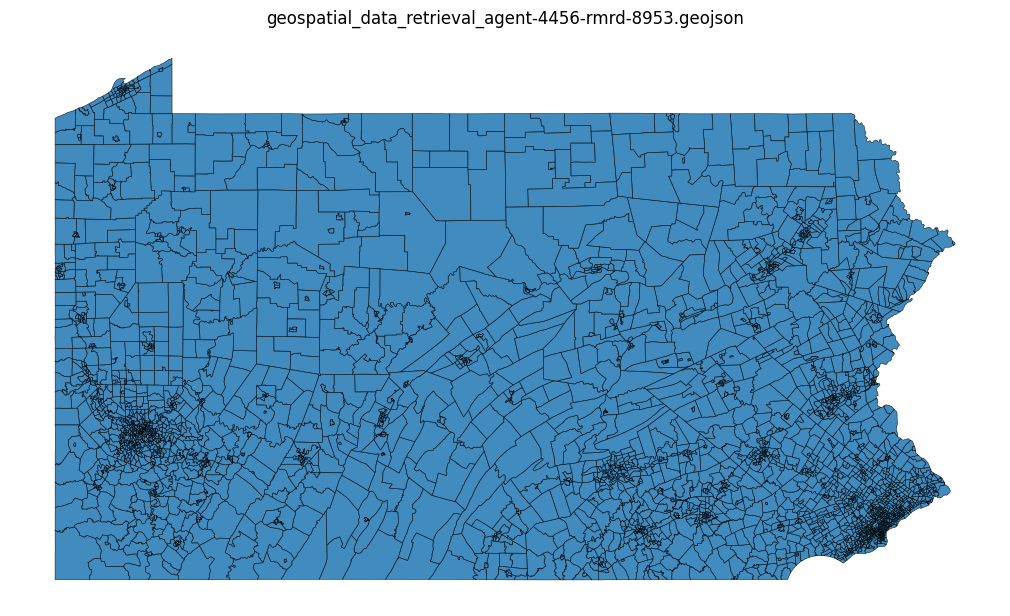

STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER
42,017,104204,1400000US42017104204,42017104204,1042.04,Census Tract 1042.04,PA,Bucks County,Pennsylvania,CT,15470934,18031
42,101,006600,1400000US42101006600,42101006600,66,Census Tract 66,PA,Philadelphia County,Pennsylvania,CT,651243,0
42,101,018802,1400000US42101018802,42101018802,188.02,Census Tract 188.02,PA,Philadelphia County,Pennsylvania,CT,252066,0
42,017,102600,1400000US42017102600,42017102600,1026,Census Tract 1026,PA,Bucks County,Pennsylvania,CT,1369894,1271
42,003,462600,1400000US42003462600,42003462600,4626,Census Tract 4626,PA,Allegheny County,Pennsylvania,CT,1086094,0


In [24]:
display_task_artifacts(pasda_task)

## 2. Geospatial Data Retrieval Agent: Streamed Census County Population Dataset

In [19]:

retrieval_task = None
for event in retrieval_agent.execute_task(
    "Download PA county population data for 2021.",
    mode="stream",
    artifact_delivery="URL",
    credentials={
        "source_credentials": {
            "US_Census_demography": {
                "key": us_census_demography_key,
            }
        }
    },
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        retrieval_task = event.get("payload")

if retrieval_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(retrieval_task)
county_population_url = first_artifact_url(retrieval_task)
county_population_url


[10:47:06] stream_connected: Streaming connection established.
[10:47:06] Geospatial Data Retrieval Agent: I received your request.
[10:47:06] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[10:47:06] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[10:47:06] task_accepted: Task accepted. Starting streaming execution.
[10:47:07] Geospatial Data Retrieval Agent: Next I will run the agent with the prepared inputs.
[10:47:07] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[10:47:07] Geospatial Data Retrieval Agent: I am comparing the request against the supported data-source handbooks to choose where the dataset should come from.
[10:47:09] Geospatial Data Retrieval Agent: The source-selection model replied successfully, so I will

'http://suspect-maroon-snowy.ngrok-free.dev/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-5796-lsdt-3210.gpkg'

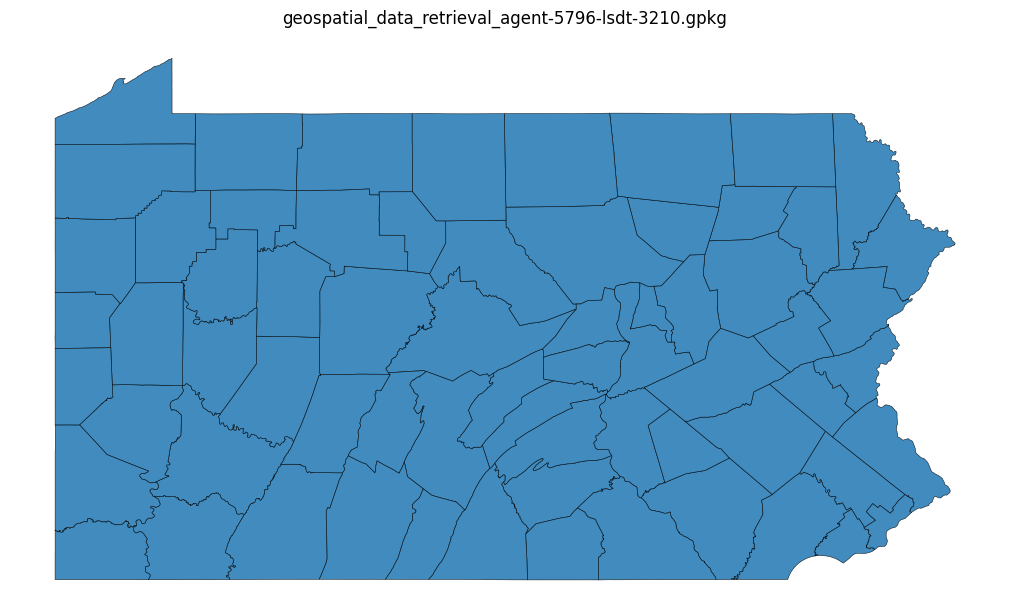

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,county_name,state_fips,county_fips,B01001_001E:Total:,year,source
42,129,01209191,0500000US42129,42129,Westmoreland,Westmoreland County,PA,Pennsylvania,06,2661762744,21294228,"Westmoreland County, Pennsylvania",42,129,355107,2021,ACS 2021
42,111,01209188,0500000US42111,42111,Somerset,Somerset County,PA,Pennsylvania,06,2784357763,17118618,"Somerset County, Pennsylvania",42,111,74331,2021,ACS 2021
42,097,01209186,0500000US42097,42097,Northumberland,Northumberland County,PA,Pennsylvania,06,1185344304,50674892,"Northumberland County, Pennsylvania",42,097,91853,2021,ACS 2021
42,131,01209192,0500000US42131,42131,Wyoming,Wyoming County,PA,Pennsylvania,06,1028873829,20040006,"Wyoming County, Pennsylvania",42,131,26389,2021,ACS 2021
42,051,01209179,0500000US42051,42051,Fayette,Fayette County,PA,Pennsylvania,06,2048054606,20636363,"Fayette County, Pennsylvania",42,051,129443,2021,ACS 2021


In [25]:
display_task_artifacts(retrieval_task)

## 3. Geospatial Data Inspection Agent: Streamed Dataset Inspection

In [21]:

inspection_task = None
for event in inspection_agent.execute_task(
    "Inspect this county population dataset. Report CRS, geometry type, feature count, useful columns, missing values, and whether it is ready for mapping and spatial analysis.",
    mode="stream",
    input_datasets=[county_population_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        inspection_task = event.get("payload")

if inspection_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(inspection_task)


[10:48:23] stream_connected: Streaming connection established.
[10:48:36] Geospatial Data Inspection Agent: I received your request.
[10:48:36] Geospatial Data Inspection Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[10:48:36] Geospatial Data Inspection Agent: I found the required credentials and can start the model-backed workflow.
[10:48:36] task_accepted: Task accepted. Starting streaming execution.
[10:48:36] Geospatial Data Inspection Agent: Next I will run the agent with the prepared inputs.
[10:48:37] Geospatial Data Inspection Agent: I will inspect the supplied datasets for geospatial quality, validation issues, and workflow readiness.
[10:48:37] Geospatial Data Inspection Agent: I am classifying each input as vector, raster, table, or unsupported before running type-specific checks.
[10:48:37] Geospatial Data Inspection Agent: Inspecting dataset 1 of 1: geospatial_data_retrieval_agent-57

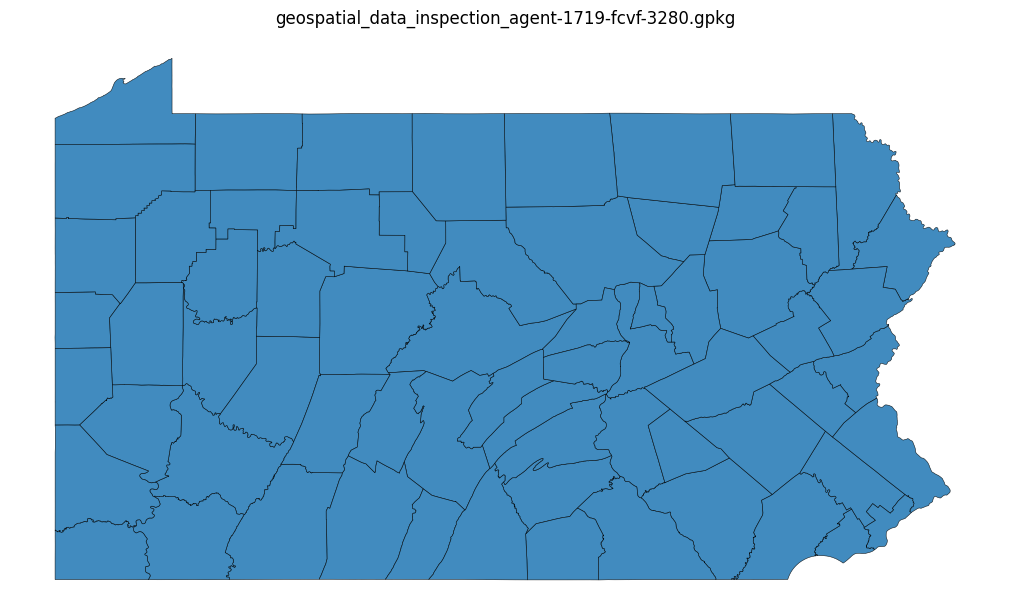

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,county_name,state_fips,county_fips,B01001_001E:Total:,year,source
42,129,01209191,0500000US42129,42129,Westmoreland,Westmoreland County,PA,Pennsylvania,06,2661762744,21294228,"Westmoreland County, Pennsylvania",42,129,355107,2021,ACS 2021
42,111,01209188,0500000US42111,42111,Somerset,Somerset County,PA,Pennsylvania,06,2784357763,17118618,"Somerset County, Pennsylvania",42,111,74331,2021,ACS 2021
42,097,01209186,0500000US42097,42097,Northumberland,Northumberland County,PA,Pennsylvania,06,1185344304,50674892,"Northumberland County, Pennsylvania",42,097,91853,2021,ACS 2021
42,131,01209192,0500000US42131,42131,Wyoming,Wyoming County,PA,Pennsylvania,06,1028873829,20040006,"Wyoming County, Pennsylvania",42,131,26389,2021,ACS 2021
42,051,01209179,0500000US42051,42051,Fayette,Fayette County,PA,Pennsylvania,06,2048054606,20636363,"Fayette County, Pennsylvania",42,051,129443,2021,ACS 2021


In [26]:
display_task_artifacts(inspection_task)

## 4. Map Projection Agent: Streamed Lambert Conformal Conic Projection

In [27]:

projection_task = None
for event in projection_agent.execute_task(
    "Project the data to Lambert Conformal Conic",
    mode="stream",
    input_datasets=[county_population_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        projection_task = event.get("payload")

if projection_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(projection_task)
projected_counties_url = first_artifact_url(projection_task, preferred_extensions=[".geojson", ".gpkg"])
projected_counties_url


[10:57:17] stream_connected: Streaming connection established.
[10:57:30] Map Projection Agent: I received your request.
[10:57:30] Map Projection Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[10:57:30] Map Projection Agent: I found the required credentials and can start the model-backed workflow.
[10:57:30] task_accepted: Task accepted. Starting streaming execution.
[10:57:30] Map Projection Agent: Next I will run the agent with the prepared inputs.
[10:57:31] Map Projection Agent: I will inspect 1 dataset reference(s), identify their current CRS, and choose an appropriate target projection for the request.
[10:57:31] Map Projection Agent: I am loading an input dataset so I can inspect its current coordinate reference system.
[10:57:31] Map Projection Agent: I am selecting a target CRS from the request text and dataset extent using local pyproj/geopandas logic.
[10:57:31] Map Projection Agent: I

'https://www.geospatial-agentic-services.online/agents/map_projection_agent/data/map_projection_agent-0497-vgnm-2270.gpkg'

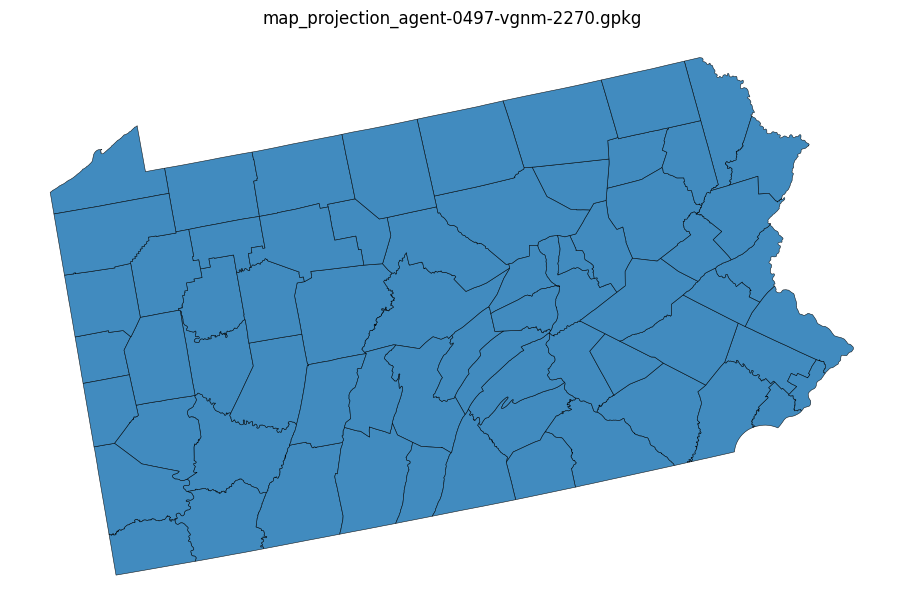

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,county_name,state_fips,county_fips,B01001_001E:Total:,year,source
42,129,01209191,0500000US42129,42129,Westmoreland,Westmoreland County,PA,Pennsylvania,06,2661762744,21294228,"Westmoreland County, Pennsylvania",42,129,355107,2021,ACS 2021
42,111,01209188,0500000US42111,42111,Somerset,Somerset County,PA,Pennsylvania,06,2784357763,17118618,"Somerset County, Pennsylvania",42,111,74331,2021,ACS 2021
42,097,01209186,0500000US42097,42097,Northumberland,Northumberland County,PA,Pennsylvania,06,1185344304,50674892,"Northumberland County, Pennsylvania",42,097,91853,2021,ACS 2021
42,131,01209192,0500000US42131,42131,Wyoming,Wyoming County,PA,Pennsylvania,06,1028873829,20040006,"Wyoming County, Pennsylvania",42,131,26389,2021,ACS 2021
42,051,01209179,0500000US42051,42051,Fayette,Fayette County,PA,Pennsylvania,06,2048054606,20636363,"Fayette County, Pennsylvania",42,051,129443,2021,ACS 2021


In [28]:
display_task_artifacts(projection_task)

## 5. Vector Analysis Agent: Streamed Vector Transformation

In [38]:

vector_task = None
for event in vector_agent.execute_task(
    (
        "Using the projected county population dataset, calculate each county's area in square kilometers, "
        "calculate population density, keep the original geometry, and return one GeoJSON dataset."
    ),
    mode="stream",
    input_datasets=[projected_counties_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        vector_task = event.get("payload")

if vector_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(vector_task)
density_counties_url = first_artifact_url(vector_task, preferred_extensions=[".geojson", ".gpkg"])
density_counties_url


[11:08:55] stream_connected: Streaming connection established.
[11:08:55] Vector Analysis Agent: I received your request.
[11:08:55] Vector Analysis Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[11:08:55] Vector Analysis Agent: I found the required credentials and can start the model-backed workflow.
[11:08:55] task_accepted: Task accepted. Starting streaming execution.
[11:08:56] Vector Analysis Agent: Next I will run the agent with the prepared inputs.
[11:08:56] Vector Analysis Agent: I will load the requested vector/tabular inputs, run code-driven analysis, and save a final dataset artifact from 1 dataset reference(s).
[11:08:56] Vector Analysis Agent: I am planning the next analysis step and deciding whether to execute code, search guidance, or register the final artifact. This is iteration 1.
[11:09:06] Vector Analysis Agent: I am still working. Long LLM calls, code execution, or geospatial

'https://www.geospatial-agentic-services.online/agents/vector_analysis_agent/data/vector_analysis_agent-3541-sznu-0180.geojson'

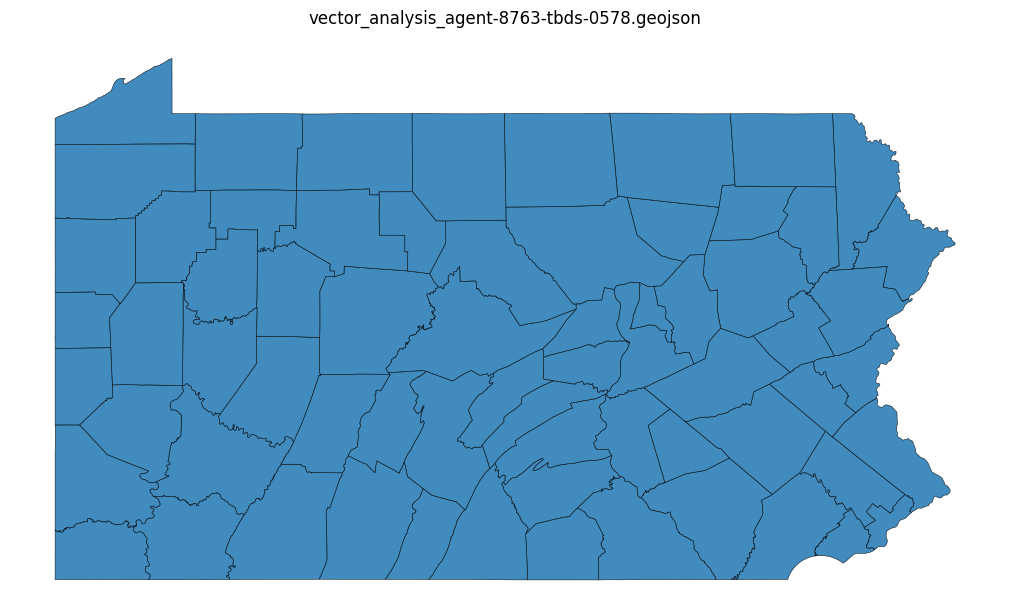

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,county_name,state_fips,county_fips,B01001_001E:Total:,year,source,area_sq_km,population,population_density_per_sq_km
42,129,01209191,0500000US42129,42129,Westmoreland,Westmoreland County,PA,Pennsylvania,06,2661762744,21294228,"Westmoreland County, Pennsylvania",42,129,355107,2021,ACS 2021,2654.992402,355107,133.750665
42,111,01209188,0500000US42111,42111,Somerset,Somerset County,PA,Pennsylvania,06,2784357763,17118618,"Somerset County, Pennsylvania",42,111,74331,2021,ACS 2021,2771.729124,74331,26.817556
42,097,01209186,0500000US42097,42097,Northumberland,Northumberland County,PA,Pennsylvania,06,1185344304,50674892,"Northumberland County, Pennsylvania",42,097,91853,2021,ACS 2021,1223.447887,91853,75.077166
42,131,01209192,0500000US42131,42131,Wyoming,Wyoming County,PA,Pennsylvania,06,1028873829,20040006,"Wyoming County, Pennsylvania",42,131,26389,2021,ACS 2021,1039.757276,26389,25.379962
42,051,01209179,0500000US42051,42051,Fayette,Fayette County,PA,Pennsylvania,06,2048054606,20636363,"Fayette County, Pennsylvania",42,051,129443,2021,ACS 2021,2046.645040,129443,63.246434


In [30]:
display_task_artifacts(vector_task)

## 6. Raster Agent: Streamed Vector-to-Raster Workflow

In [39]:

raster_task = None
for event in raster_agent.execute_task(
    (
        "Rasterize the Pennsylvania county polygons.Use the 'population_density' field as pixel values. Use 100-meter pixels."

    ),
    mode="stream",
    input_datasets=[density_counties_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        raster_task = event.get("payload")

if raster_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(raster_task)
raster_url = first_artifact_url(raster_task, preferred_extensions=[".tif", ".tiff"])
raster_url


[11:10:07] stream_connected: Streaming connection established.
[11:10:08] Raster Agent: I received your request.
[11:10:08] Raster Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[11:10:08] Raster Agent: I found the required credentials and can start the model-backed workflow.
[11:10:08] task_accepted: Task accepted. Starting streaming execution.
[11:10:08] Raster Agent: Next I will run the agent with the prepared inputs.
[11:10:08] Raster Agent: I will inspect the raster or mixed raster-vector inputs, run code-driven processing, and save a final artifact from 1 dataset reference(s).
[11:10:09] Raster Agent: I directly rasterized the vector dataset with a georeferenced profile, so I can save the GeoTIFF without additional model-generated code.
[11:10:09] Raster Agent: I am saving the registered raster/vector result and collecting its output metadata.
[11:10:09] Raster Agent: The agent finished its w

'http://suspect-maroon-snowy.ngrok-free.dev/agents/raster_agent/data/raster_agent-2887-wuid-1528.tif'

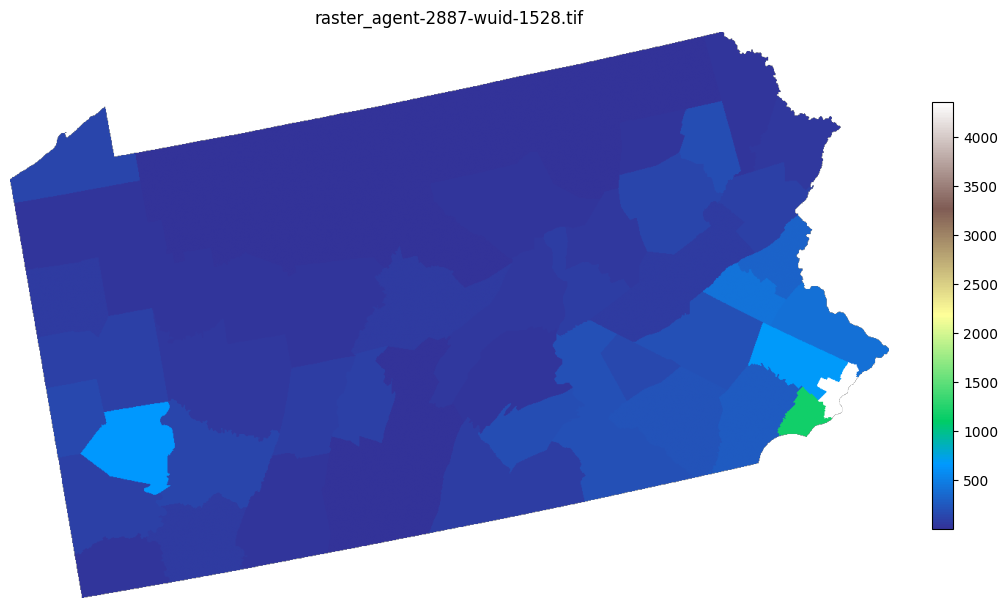

In [40]:
display_task_artifacts(raster_task)

## 7. Spatial Statistics Agent: Streamed Autocorrelation Analysis

In [41]:

statistics_task = None
for event in statistics_agent.execute_task(
    (
        "Check the spatial autocorrelation of county population density. Use queen contiguity weights if appropriate, "
        "and return a concise report plus any useful diagnostic artifact."
    ),
    mode="stream",
    input_datasets=[density_counties_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        statistics_task = event.get("payload")

if statistics_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(statistics_task)


[11:10:54] stream_connected: Streaming connection established.
[11:10:54] Spatial Statistics Agent: I received your request.
[11:10:54] Spatial Statistics Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[11:10:54] Spatial Statistics Agent: I found the required credentials and can start the model-backed workflow.
[11:10:55] task_accepted: Task accepted. Starting streaming execution.
[11:10:55] Spatial Statistics Agent: Next I will run the agent with the prepared inputs.
[11:10:55] Spatial Statistics Agent: I will inspect the datasets, choose suitable PySAL methods, generate analysis code, and return a modeling report.
[11:10:55] Spatial Statistics Agent: I am inspecting the input datasets to identify geometry types, CRS, numeric fields, candidate modeling variables, and usable PySAL workflows.
[11:10:55] Spatial Statistics Agent: Dataset inspection is complete. I identified candidate variables, geome

In [42]:
display_task_artifacts(statistics_task)

## 8. Mapping Agent: Streamed Static Choropleth Map

In [51]:

mapping_task = None
for event in mapping_agent.execute_task(
    (
        "Create a county-level choropleth map for the PA showing 2021 population density. "
        "Use a quantile classification scheme with 5 classes. Use a sequential palette where the lowest class is visibly light blue, not white. "
        "Draw missing values in light gray and use thin county outlines. ."
    ),
    mode="stream",
    input_datasets=[density_counties_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        mapping_task = event.get("payload")

if mapping_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(mapping_task)


[11:27:01] stream_connected: Streaming connection established.
[11:27:02] Mapping Agent: I received your request.
[11:27:02] Mapping Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[11:27:02] Mapping Agent: I found the required credentials and can start the model-backed workflow.
[11:27:02] task_accepted: Task accepted. Starting streaming execution.
[11:27:03] Mapping Agent: Next I will run the agent with the prepared inputs.
[11:27:03] Mapping Agent: I will inspect the requested visualization and the 1 dataset reference(s), then choose whether a map or chart is the best way to answer it.
[11:27:03] Mapping Agent: I am drafting visualization code now. This is attempt 1; I will run the code and check whether it creates the requested output correctly.
[11:27:13] Mapping Agent: I am still working. Long LLM calls, code execution, or geospatial file processing can take a little while.
[11:27:23] Mapping 

In [52]:
display_task_artifacts(mapping_task)

## 9. Web Mapping App Agent: Streamed Web Mapping App

In [70]:

interactive_task = None
for event in web_mapping_app_agent.execute_task(
    (
      "Create a polished browser-ready interactive web mapping app for Pennsylvania county population."
      "Display county polygons as a choropleth map with a clear sequential color scheme."
      "Include hover tooltips and click popups showing relevant information. Add a professional title, a "
      "brief explanatory side panel on the left, a Pennsylvania-focused initial extent, useful "
      "basemap options, and a visible layer control. Return one self-contained HTML file."
    ),
    mode="stream",
    input_datasets=[county_population_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        interactive_task = event.get("payload")

if interactive_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(interactive_task)

[12:43:56] stream_connected: Streaming connection established.
[12:44:00] Web Mapping App Agent: I received your request.
[12:44:00] Web Mapping App Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[12:44:01] Web Mapping App Agent: I found the required credentials and can start the model-backed workflow.
[12:44:01] task_accepted: Task accepted. Starting streaming execution.
[12:44:01] Web Mapping App Agent: Next I will run the agent with the prepared inputs.
[12:44:01] Web Mapping App Agent: I will inspect the input datasets, design the web mapping app, generate the app code, and save an HTML artifact.
[12:44:01] Web Mapping App Agent: I am inspecting 1 dataset reference(s) to identify formats, CRS, geometry types, fields, and bounds.
[12:44:01] Web Mapping App Agent: I reprojected geospatial_data_retrieval_agent-5796-lsdt-3210.gpkg to EPSG:4326 so the web map can render it correctly in Leaflet.
[12:

In [71]:
display_task_artifacts(interactive_task)

## Final Artifact URLs

In [72]:
all_tasks = {
    "pasda": pasda_task,
    "retrieval": retrieval_task,
    "inspection": inspection_task,
    "projection": projection_task,
    "vector_analysis": vector_task,
    "raster": raster_task,
    "spatial_statistics": statistics_task,
    "mapping": mapping_task,
    "interactive_mapping": interactive_task,
}

for name, task_result in all_tasks.items():
    print("\n" + name)
    for artifact in task_result.get("outputs", {}).get("artifacts", []):
        if artifact.get("url"):
            print("-", artifact.get("filename") or artifact.get("name"), artifact["url"])


pasda
- geospatial_data_retrieval_agent-4456-rmrd-8953.geojson http://suspect-maroon-snowy.ngrok-free.dev/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-4456-rmrd-8953.geojson

retrieval
- geospatial_data_retrieval_agent-5796-lsdt-3210.gpkg http://suspect-maroon-snowy.ngrok-free.dev/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-5796-lsdt-3210.gpkg

inspection
- geospatial_data_inspection_agent-6627-rilj-7050.txt https://www.geospatial-agentic-services.online/agents/geospatial_data_inspection_agent/data/geospatial_data_inspection_agent-6627-rilj-7050.txt
- geospatial_data_inspection_agent-3617-wcag-8254.html https://www.geospatial-agentic-services.online/agents/geospatial_data_inspection_agent/data/geospatial_data_inspection_agent-3617-wcag-8254.html
- geospatial_data_inspection_agent-1719-fcvf-3280.gpkg https://www.geospatial-agentic-services.online/agents/geospatial_data_inspection_agent/data/geospatial_data_inspection_agent-